# Cleaning And Structuring

This notebook reruns the UFC data-cleaning pipeline and highlights the new pre-fight context features added for modeling.

Key updates in this version:
- cleaned weight-class labels from `bout_type`
- pre-fight win and loss streaks
- past-opponent strength summaries built from opponents' pre-fight records
- per-fight and per-minute cumulative features for striking, grappling, control, and knockdowns
- preservation of the existing power, durability, and opponent-adjusted power features


In [ ]:
from pathlib import Path
import sys
import importlib

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

import pandas as pd
import src.combined_data as combined_data_module

combined_data_module = importlib.reload(combined_data_module)
build_combined_dataset = combined_data_module.build_combined_dataset

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)

combined_df, created_columns = build_combined_dataset()
combined_df.shape


fight data shape: (8591, 60)
fight data first columns: ['red_fighter_name', 'blue_fighter_name', 'event_date', 'red_fighter_nickname', 'blue_fighter_nickname', 'red_fighter_result', 'blue_fighter_result', 'fight_outcome']
fight data delimiter detected: ';'
raw fighter statistics shape: (3596, 14)
raw fighter statistics first columns: ['fighter_name', 'Height', 'Weight', 'Reach', 'Stance', 'DOB', 'SLpM', 'Str_Acc']
raw fighter statistics delimiter detected: ','
Merged fighter attribute missingness (%):
red_fighter_height     10.27
blue_fighter_height    13.13
red_fighter_reach      15.75
blue_fighter_reach     24.72
red_fighter_dob        10.88
blue_fighter_dob       15.02
dtype: float64
Red unmatched fighter examples: ['MARWAN RAHIKI', 'CHARLES JOHNSON', 'BIA MESQUITA', 'VITOR PETRINO', 'PIERA RODRIGUEZ', 'ELIJAH SMITH', 'LUAN LACERDA', 'BOLAJI OKI', 'LUKE RILEY', 'IWO BARANIEWSKI']
Blue unmatched fighter examples: ['KEVIN VALLEJOS', 'OUMAR SY', 'HARRY HARDWICK', 'JOSE DELGADO', 'MONTS

(8591, 699)

## What Was Cleaned And Constructed

The pipeline still uses only pre-fight or static information when building modeling features. Current-fight values remain in the table for reference, but all `pre_fight_*` columns are generated chronologically before each fight is processed.

Past-opponent strength is built by storing each opponent's pre-fight win percentage, total wins, and total fights at the time they were faced, then averaging those values across a fighter's prior opponents. That keeps the feature fully pre-fight and avoids peeking at future opponent performance.

Fighter bio data still depends on coverage in `raw_fighter_statistics.csv`, so some height, reach, stance, DOB, and age values can remain missing for fighters who are not present in that source file.


In [2]:
feature_preview_columns = [
    'event_date',
    'weight_class_clean',
    'red_fighter_name',
    'blue_fighter_name',
    'pre_fight_red_win_streak',
    'pre_fight_blue_win_streak',
    'pre_fight_red_loss_streak',
    'pre_fight_blue_loss_streak',
    'pre_fight_red_avg_past_opponent_win_pct',
    'pre_fight_blue_avg_past_opponent_win_pct',
    'pre_fight_red_years_in_ufc',
    'pre_fight_blue_years_in_ufc',
    'pre_fight_red_fights_per_year',
    'pre_fight_blue_fights_per_year',
    'pre_fight_red_sig_strikes_landed_per_fight',
    'pre_fight_blue_sig_strikes_landed_per_fight',
    'pre_fight_red_sig_strikes_landed_per_min',
    'pre_fight_blue_sig_strikes_landed_per_min',
    'pre_fight_red_td_accuracy',
    'pre_fight_blue_td_accuracy',
    'pre_fight_red_td_defense',
    'pre_fight_blue_td_defense',
    'diff_win_streak',
    'diff_avg_past_opponent_win_pct',
    'diff_years_in_ufc',
    'diff_sig_strikes_landed_per_fight',
    'diff_td_accuracy',
]

combined_df[feature_preview_columns].head(10)


,event_date,weight_class_clean,red_fighter_name,blue_fighter_name,pre_fight_red_win_streak,pre_fight_blue_win_streak,pre_fight_red_loss_streak,pre_fight_blue_loss_streak,pre_fight_red_avg_past_opponent_win_pct,pre_fight_blue_avg_past_opponent_win_pct,pre_fight_red_years_in_ufc,pre_fight_blue_years_in_ufc,pre_fight_red_fights_per_year,pre_fight_blue_fights_per_year,pre_fight_red_sig_strikes_landed_per_fight,pre_fight_blue_sig_strikes_landed_per_fight,pre_fight_red_sig_strikes_landed_per_min,pre_fight_blue_sig_strikes_landed_per_min,pre_fight_red_td_accuracy,pre_fight_blue_td_accuracy,pre_fight_red_td_defense,pre_fight_blue_td_defense,diff_win_streak,diff_avg_past_opponent_win_pct,diff_years_in_ufc,diff_sig_strikes_landed_per_fight,diff_td_accuracy
0,2026-03-14,Featherweight,JOSH EMMETT,KEVIN VALLEJOS,0.0,3.0,2.0,0.0,0.677240,0.709091,9.848049,0.996578,1.624687,3.010302,48.250000,41.333333,0.0,0.0,0.375000,0.333333,0.437500,0.888889,-3.0,-0.031851,8.851472,6.916667,0.041667
1,2026-03-14,Women's Strawweight,AMANDA LEMOS,GILLIAN ROBERTSON,0.0,4.0,1.0,0.0,0.738763,0.473380,8.659822,8.281999,1.616661,2.294132,28.785714,28.842105,0.0,0.0,0.625000,0.406977,0.641026,0.411765,-4.0,0.265382,0.377823,-0.056391,0.218023
2,2026-03-14,Light Heavyweight,ION CUTELABA,OUMAR SY,0.0,1.0,1.0,0.0,0.617064,0.375000,9.735797,1.820671,1.951561,2.196992,34.789474,35.250000,0.0,0.0,0.493671,0.368421,0.750000,1.000000,-1.0,0.242064,7.915127,-0.460526,0.125250
3,2026-03-14,Featherweight,MARWAN RAHIKI,HARRY HARDWICK,0.0,0.0,0.0,1.0,0.000000,0.666667,0.000000,0.517454,0.000000,1.932540,0.000000,8.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,-0.666667,-0.517454,-8.000000,0.000000
4,2026-03-14,Featherweight,ANDRE FILI,JOSE DELGADO,1.0,0.0,0.0,1.0,0.558788,0.583333,12.399726,1.073238,2.016174,2.795281,40.760000,54.666667,0.0,0.0,0.453488,0.000000,0.717949,0.428571,1.0,-0.024545,11.326489,-13.906667,0.453488
5,2026-03-14,Flyweight,CHARLES JOHNSON,BRUNO SILVA,0.0,1.0,1.0,0.0,0.672189,0.466918,3.641342,6.439425,3.570113,3.261161,58.615385,36.904762,0.0,0.0,0.200000,0.272727,0.669725,0.712121,-1.0,0.205271,-2.798084,21.710623,-0.072727
6,2026-03-14,Women's Bantamweight,BIA MESQUITA,MONTSE RENDON,1.0,1.0,0.0,0.0,0.333333,0.333333,0.421629,2.472279,2.371753,1.213455,36.000000,46.333333,0.0,0.0,0.666667,0.375000,0.000000,1.000000,0.0,0.000000,-2.050650,-10.333333,0.291667
7,2026-03-14,Heavyweight,VITOR PETRINO,STEVEN ASPLUND,2.0,1.0,0.0,0.0,0.412500,0.000000,3.008898,0.249144,2.658781,4.013736,25.250000,170.000000,0.0,0.0,0.514286,0.000000,0.807692,1.000000,1.0,0.412500,2.759754,-144.750000,0.514286
8,2026-03-14,Welterweight,CHRIS CURTIS,MYKTYBEK OROLBAI,1.0,2.0,0.0,0.0,0.678559,0.622222,4.350445,2.318960,2.528477,2.156139,76.000000,30.200000,0.0,0.0,0.000000,0.459459,0.827586,0.400000,-1.0,0.056336,2.031485,45.800000,-0.459459
9,2026-03-14,Women's Strawweight,PIERA RODRIGUEZ,SAM HUGHES,2.0,3.0,0.0,0.0,0.558120,0.643939,3.928816,5.251198,1.527178,2.094760,47.500000,57.545455,0.0,0.0,0.657895,0.352941,0.733333,0.608696,-1.0,-0.085820,-1.322382,-10.045455,0.304954


## Bio Attribute Coverage

The merged fighter bio fields are useful when available, but the source coverage is still incomplete for some fighters. This summary makes that visible before modeling.


In [3]:
bio_columns = [
    'red_fighter_height', 'blue_fighter_height',
    'red_fighter_reach', 'blue_fighter_reach',
    'red_fighter_dob', 'blue_fighter_dob',
    'red_fighter_age', 'blue_fighter_age',
]

combined_df[bio_columns].isna().mean().sort_values().to_frame(name="missing_rate")


,missing_rate
red_fighter_height,0.102666
red_fighter_dob,0.108835
red_fighter_age,0.108835
blue_fighter_height,0.131300
blue_fighter_dob,0.150157
blue_fighter_age,0.150157
red_fighter_reach,0.157490
blue_fighter_reach,0.247235


## Example Fighter Histories

These rows help sanity-check that streaks and opponent-strength features move forward over time rather than reacting to the current fight.


In [4]:
sample_fighters = [name for name in pd.concat([combined_df["red_fighter_name"], combined_df["blue_fighter_name"]]).value_counts().head(3).index]
history_columns = [
    'event_date', 'red_fighter_name', 'blue_fighter_name',
    'pre_fight_red_total_fights', 'pre_fight_blue_total_fights',
    'pre_fight_red_win_streak', 'pre_fight_blue_win_streak',
    'pre_fight_red_avg_past_opponent_win_pct', 'pre_fight_blue_avg_past_opponent_win_pct',
    'pre_fight_red_power_index', 'pre_fight_blue_power_index',
    'pre_fight_red_durability_index', 'pre_fight_blue_durability_index',
]

pd.concat([
    combined_df.loc[(combined_df["red_fighter_name"] == fighter) | (combined_df["blue_fighter_name"] == fighter), history_columns]
    .sort_values("event_date")
    .head(6)
    for fighter in sample_fighters
])


,event_date,red_fighter_name,blue_fighter_name,pre_fight_red_total_fights,pre_fight_blue_total_fights,pre_fight_red_win_streak,pre_fight_blue_win_streak,pre_fight_red_avg_past_opponent_win_pct,pre_fight_blue_avg_past_opponent_win_pct,pre_fight_red_power_index,pre_fight_blue_power_index,pre_fight_red_durability_index,pre_fight_blue_durability_index
7631,2008-10-18,JIM MILLER,DAVID BARON,0.0,0.0,0.0,0.0,0.000000,0.000000,-0.381391,-0.381391,0.275320,0.275320
7587,2008-12-10,JIM MILLER,MATT WIMAN,1.0,5.0,1.0,4.0,0.000000,0.283333,-0.381391,0.297433,0.275320,-0.299683
7516,2009-03-07,GRAY MAYNARD,JIM MILLER,5.0,2.0,4.0,2.0,0.425000,0.400000,0.218941,-0.381391,0.275320,0.275320
7486,2009-07-11,JIM MILLER,MAC DANZIG,3.0,4.0,0.0,0.0,0.533333,0.357143,-0.381391,-0.152110,0.275320,0.275320
7416,2009-09-19,JIM MILLER,STEVE LOPEZ,4.0,0.0,1.0,0.0,0.525000,0.000000,-0.381391,-0.381391,0.275320,0.275320
7349,2010-01-02,JIM MILLER,DUANE LUDWIG,5.0,2.0,2.0,2.0,0.420000,1.000000,-0.007971,0.897228,0.275320,0.275320
8332,2000-11-17,ANDREI ARLOVSKI,AARON BRINK,0.0,0.0,0.0,0.0,0.000000,0.000000,-0.381391,-0.381391,0.275320,0.275320
8318,2001-06-29,RICCO RODRIGUEZ,ANDREI ARLOVSKI,0.0,1.0,0.0,1.0,0.000000,0.000000,-0.381391,-0.381391,0.275320,0.275320
8298,2002-03-22,PEDRO RIZZO,ANDREI ARLOVSKI,9.0,2.0,0.0,0.0,0.776455,0.000000,1.181601,-0.381391,0.078198,-0.611727
8246,2002-11-22,ANDREI ARLOVSKI,IAN FREEMAN,3.0,4.0,0.0,3.0,0.222222,0.500000,-0.381391,0.314399,-1.261132,0.275320


In [5]:
output_path = Path("data/combined_statistics.csv")
output_path.exists(), output_path


(False, PosixPath('data/combined_statistics.csv'))

## Downstream Modeling Note

The cleaned dataset keeps the full engineered feature surface, but the modeling pipeline now explicitly **cuts the modeling universe to fights on or after `2010-01-01`**.

Why we made that change:
- the year-by-year red win rate is near 100% for much of the pre-2010 history
- that pattern strongly suggests the older source does not use a stable red/blue corner convention
- training across that regime break would make the target itself inconsistent over time

So the full table remains useful for EDA and raw history inspection, while downstream modeling, odds matching, walk-forward research, and betting analysis all use the post-2009 subset only.


## Final EDA Visuals

These plots are descriptive only. They help us sanity-check dataset coverage and fight-history distributions without changing any engineered features or model outputs.


In [6]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

repo_root = Path.cwd()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
figures_dir = repo_root / 'outputs' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

combined = pd.read_csv(repo_root / 'data' / 'combined_statistics.csv', parse_dates=['event_date'])
combined['event_year'] = combined['event_date'].dt.year


/var/folders/f5/ysl_br0d1h5bzctjs30jkv_c0000gn/T/ipykernel_82738/4172958801.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined['event_year'] = combined['event_date'].dt.year


### Number of Fights By Year

A quick count by calendar year helps show where the dataset is dense and where early UFC history is thin.


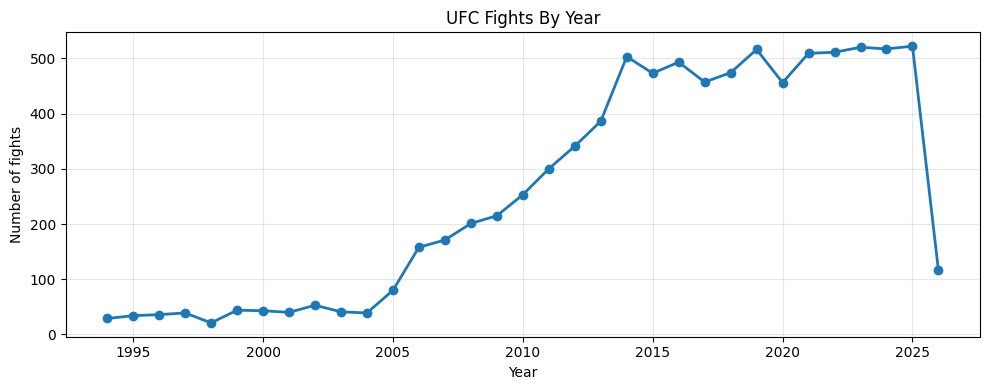

In [7]:
fights_by_year = combined.groupby('event_year').size()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fights_by_year.index, fights_by_year.values, marker='o', linewidth=2)
ax.set_title('UFC Fights By Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of fights')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(figures_dir / '02_fights_by_year.png', dpi=150, bbox_inches='tight')
plt.show()


### Red Win Rate By Year

This plot is now an important quality-control check. The sharp drop from near-100% red wins in the early years to a much more stable post-2010 range is evidence of a **corner-assignment regime break** in the historical source data rather than a believable competitive effect.

That is why the modeling workflow excludes fights before `2010-01-01`.


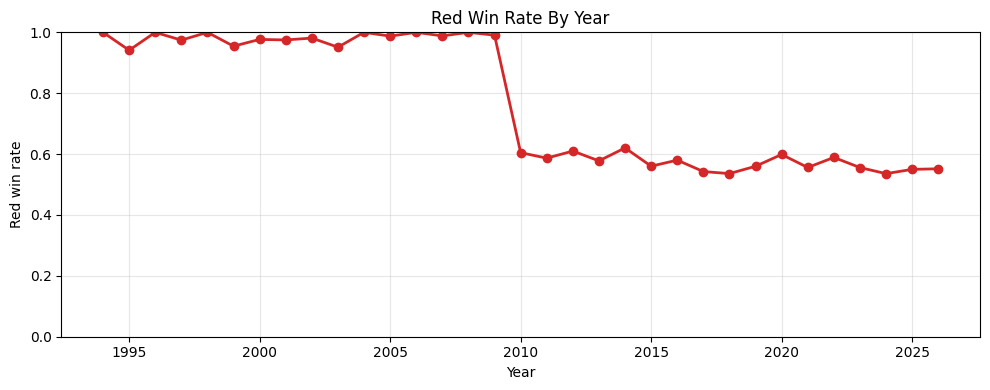

In [8]:
red_win_by_year = combined.groupby('event_year')['red_win'].mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(red_win_by_year.index, red_win_by_year.values, marker='o', color='tab:red', linewidth=2)
ax.set_title('Red Win Rate By Year')
ax.set_xlabel('Year')
ax.set_ylabel('Red win rate')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(figures_dir / '02_red_win_rate_by_year.png', dpi=150, bbox_inches='tight')
plt.show()


### Distribution of Pre-Fight Experience

This histogram pools red and blue pre-fight fight counts so we can see how much of the sample comes from newcomers versus experienced UFC fighters.


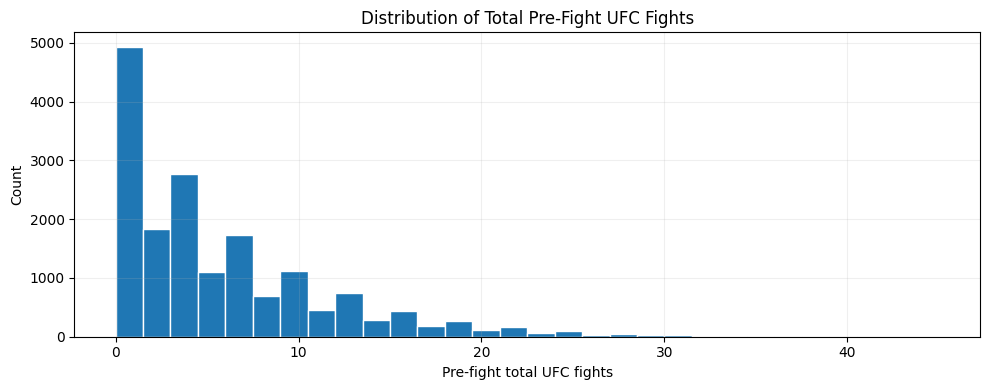

In [9]:
experience = pd.concat([
    combined['pre_fight_red_total_fights'],
    combined['pre_fight_blue_total_fights'],
], axis=0).dropna()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(experience, bins=30, color='tab:blue', edgecolor='white')
ax.set_title('Distribution of Total Pre-Fight UFC Fights')
ax.set_xlabel('Pre-fight total UFC fights')
ax.set_ylabel('Count')
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(figures_dir / '02_pre_fight_experience_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## Downstream Research Readiness

The cleaned dataset in this notebook is still the base for every downstream stage, but the **modeling universe is intentionally narrower than the full raw history**.

Publication-ready rule:
- keep the full engineered fight table for descriptive analysis
- fit models only on fights dated `2010-01-01` or later
- carry that same cutoff into the final test benchmark, odds merge, betting backtest, walk-forward study, and audit
